<a href="https://colab.research.google.com/github/ojohnso3-oss/ojohnso3-INST414/blob/main/Medium4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [40]:
movies = pd.read_csv("/content/sample_data/imdb_top_1000.csv")

In [41]:
print("Dataset shape:", movies.shape)
print("\nColumns:")
print(movies.columns.tolist())
print("\nFirst 5 rows:")
print(movies.head().to_string())

Dataset shape: (1000, 16)

Columns:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

First 5 rows:
                                                                                                                                         Poster_Link              Series_Title Released_Year Certificate  Runtime                 Genre  IMDB_Rating                                                                                                                                                                                       Overview  Meta_score              Director           Star1           Star2          Star3           Star4  No_of_Votes        Gross
0  https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg  The Shawshank Redemption          1994     

In [42]:
cols_needed = [
    "Series_Title",
    "Genre",
    "IMDB_Rating",
    "Runtime",
    "No_of_Votes",
    "Released_Year"
]

movies = movies[cols_needed].copy()

In [43]:
# Clean Runtime: convert "142 min" -> 142
movies["Runtime"] = movies["Runtime"].str.replace(" min", "", regex=False)
movies["Runtime"] = pd.to_numeric(movies["Runtime"], errors="coerce")

# Clean Released_Year
movies["Released_Year"] = pd.to_numeric(movies["Released_Year"], errors="coerce")

# Clean IMDB_Rating
movies["IMDB_Rating"] = pd.to_numeric(movies["IMDB_Rating"], errors="coerce")

# Clean No_of_Votes
movies["No_of_Votes"] = pd.to_numeric(movies["No_of_Votes"], errors="coerce")

# Handle missing values in numeric columns
numeric_cols = ["IMDB_Rating", "Runtime", "No_of_Votes", "Released_Year"]
for col in numeric_cols:
    movies[col] = movies[col].fillna(movies[col].median())

# Handle missing genres
movies["Genre"] = movies["Genre"].fillna("Unknown").astype(str)

# Log-transform votes to reduce skew
movies["No_of_Votes"] = np.log1p(movies["No_of_Votes"])

print("\nMissing values after cleaning:")
print(movies.isna().sum())



Missing values after cleaning:
Series_Title     0
Genre            0
IMDB_Rating      0
Runtime          0
No_of_Votes      0
Released_Year    0
dtype: int64


In [44]:
# one-hot encode genre

genre_dummies = movies["Genre"].str.get_dummies(sep=",")

# Remove leading/trailing spaces from genre dummy column names
genre_dummies.columns = [col.strip() for col in genre_dummies.columns]

# Combine numeric + genre features
X = pd.concat([
    movies[["IMDB_Rating", "Runtime", "No_of_Votes", "Released_Year"]],
    genre_dummies
], axis=1)

print("\nFeature matrix shape:", X.shape)
print("Feature columns:")
print(X.columns.tolist())


Feature matrix shape: (1000, 38)
Feature columns:
['IMDB_Rating', 'Runtime', 'No_of_Votes', 'Released_Year', 'Action', 'Adventure', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western', 'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Horror', 'Mystery', 'Thriller', 'Western']


In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (1000, 38)


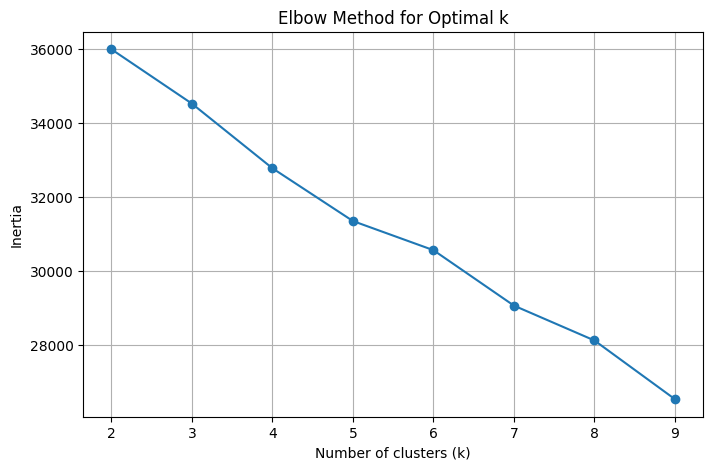

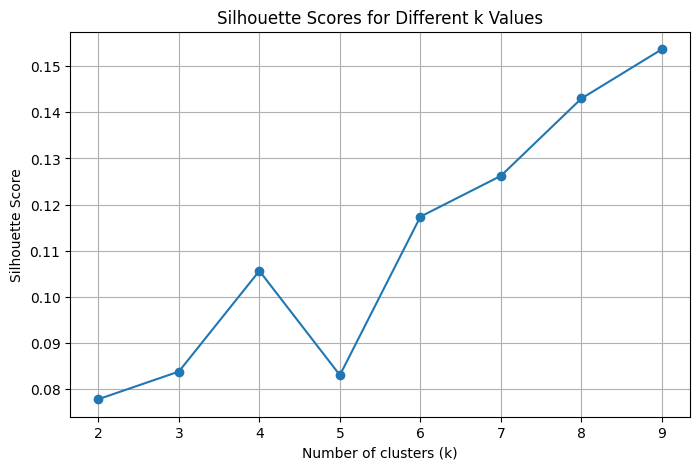


Best k based on silhouette score: 9


In [46]:
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k Values")
plt.grid(True)
plt.show()

best_k = list(k_values)[np.argmax(sil_scores)]
print("\nBest k based on silhouette score:", best_k)

In [47]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
movies["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(movies["cluster"].value_counts().sort_index())


Cluster counts:
cluster
0    318
1    251
2    316
3    115
Name: count, dtype: int64


In [48]:
cluster_summary = movies.groupby("cluster")[numeric_cols].agg(["mean", "median", "count"])

print("\nCluster summary:")
print(cluster_summary)


Cluster summary:
        IMDB_Rating                  Runtime              No_of_Votes  \
               mean median count        mean median count        mean   
cluster                                                                 
0          7.961321    8.0   318  123.805031  120.0   318   11.642932   
1          7.946215    7.9   251  119.175299  115.0   251   12.248465   
2          7.916772    7.9   316  124.110759  120.0   316   11.844423   
3          8.012174    8.0   115  125.121739  119.0   115   12.063279   

                         Released_Year                
            median count          mean  median count  
cluster                                               
0        11.401403   318   1987.371069  1996.0   318  
1        12.336052   251   1998.964143  2004.0   251  
2        11.748977   316   1990.060127  1997.0   316  
3        11.911225   115   1988.191304  1995.0   115  


In [52]:
#example of the 4 movies in each cluster

for cluster_id in sorted(movies["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    example_movies = movies[movies["cluster"] == cluster_id][
        ["Series_Title", "Genre", "IMDB_Rating", "Runtime", "No_of_Votes", "Released_Year"]
    ].head(5)
    print(example_movies.to_string(index=False))


Cluster 0
                   Series_Title          Genre  IMDB_Rating  Runtime  No_of_Votes  Released_Year
       The Shawshank Redemption          Drama          9.3      142    14.666990         1994.0
                     Fight Club          Drama          8.8      139    14.433256         1999.0
                   Forrest Gump Drama, Romance          8.8      142    14.408407         1994.0
Il buono, il brutto, il cattivo        Western          8.8      161    13.442112         1966.0
One Flew Over the Cuckoo's Nest          Drama          8.7      133    13.730050         1975.0

Cluster 1
                                     Series_Title                     Genre  IMDB_Rating  Runtime  No_of_Votes  Released_Year
                                  The Dark Knight      Action, Crime, Drama          9.0      152    14.649824         2008.0
    The Lord of the Rings: The Return of the King  Action, Adventure, Drama          8.9      201    14.311888         2003.0
                  